In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import re
import os

In [2]:
# Sentiment tools (try multiple fallbacks)
try:
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    sid = SentimentIntensityAnalyzer()
except Exception:
    sid = None

In [3]:
df = pd.read_csv("Data_Cleaned_Starbucks.csv")
df.head()

,store name,ownership type,city,review number,author,date,rating,review,month,year
0,New Oxford Street,Company Owned,London,1,Elena Martellucci,2024-06-21 21:18:08,5,"we had coffee, pastries, and a latte. it's a g...",6,2024
1,New Oxford Street,Company Owned,London,2,Anastasia Mikha,2024-06-21 22:54:06,3,i came to the establishment for my birthday (t...,6,2024
2,New Oxford Street,Company Owned,London,3,Parts LMC,2024-06-22 11:48:43,4,never disappointed with the drinks! always ver...,6,2024
3,New Oxford Street,Company Owned,London,4,Jennifer,2024-06-26 14:16:57,1,i was disappointed with this starburst in oxfo...,6,2024
4,New Oxford Street,Company Owned,London,5,Tri Ngo Minh,2024-07-05 09:43:29,5,https://lh3.googleusercontent.com/geougc-cs/am...,7,2024


In [4]:
# 1) Rating distribution & variability per store / city / ownership type

# Produces: counts and percent distribution, std dev of ratings


def rating_distribution(df, groupby_col='store name'):
    agg = df.groupby(groupby_col)['rating'].agg(['count','mean','std'])
    dist = df.pivot_table(index=groupby_col, columns='rating', values='review', aggfunc='count', fill_value=0)
# convert counts to percents
    perc = dist.div(dist.sum(axis=1), axis=0).fillna(0)
    res = agg.join(perc)
    return res.sort_values('mean', ascending=False)


# Example usage:
rd_store = rating_distribution(df, 'store name')
rd_city = rating_distribution(df, 'city')
print(rd_store.head())

                                 count  mean       std         1         2  \
store name                                                                   
Manchester - Piccadilly Station    100  4.91  0.350901  0.000000  0.000000   
SSP Manchester Victoria            100  4.83  0.493493  0.000000  0.020408   
SSP King's Cross Main Concourse    100  4.68  0.941523  0.058824  0.000000   
SSP Birmingham New St              100  4.64  1.049483  0.063158  0.021053   
The Lion, 1 Junction               100  4.63  1.021536  0.085714  0.000000   

                                        3         4         5  
store name                                                     
Manchester - Piccadilly Station  0.017857  0.071429  0.910714  
SSP Manchester Victoria          0.040816  0.081633  0.857143  
SSP King's Cross Main Concourse  0.000000  0.058824  0.882353  
SSP Birmingham New St            0.010526  0.031579  0.873684  
The Lion, 1 Junction             0.057143  0.057143  0.800000  


In [1]:
def plot_monthly_trends_by_year(df):
    # Parse dates safely
    df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)
    df = df.dropna(subset=['date'])

    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month

    # Get all unique years sorted
    years = sorted(df['year'].unique())

    # Create subplots — one per year
    fig, axes = plt.subplots(len(years), 1, figsize=(12, 3 * len(years)), sharex=False)

    if len(years) == 1:
        axes = [axes]  # handle case of only one year

    for ax, yr in zip(axes, years):
        df_year = df[df['year'] == yr]

        # Monthly aggregation
        monthly = df_year.groupby('month')['rating'].mean().reset_index()

        # Plot
        ax.plot(monthly['month'], monthly['rating'], marker='o')
        ax.set_title(f"Monthly Average Rating – {yr}")
        ax.set_ylabel("Avg Rating")
        ax.set_xticks(range(1,13))
        ax.set_xticklabels(
            ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            rotation=45
        )
        ax.grid(alpha=0.2)
        ax.set_ylim(1, 5)

    plt.tight_layout()
    plt.show()


plot_monthly_trends_by_year(df)

NameError: name 'df' is not defined

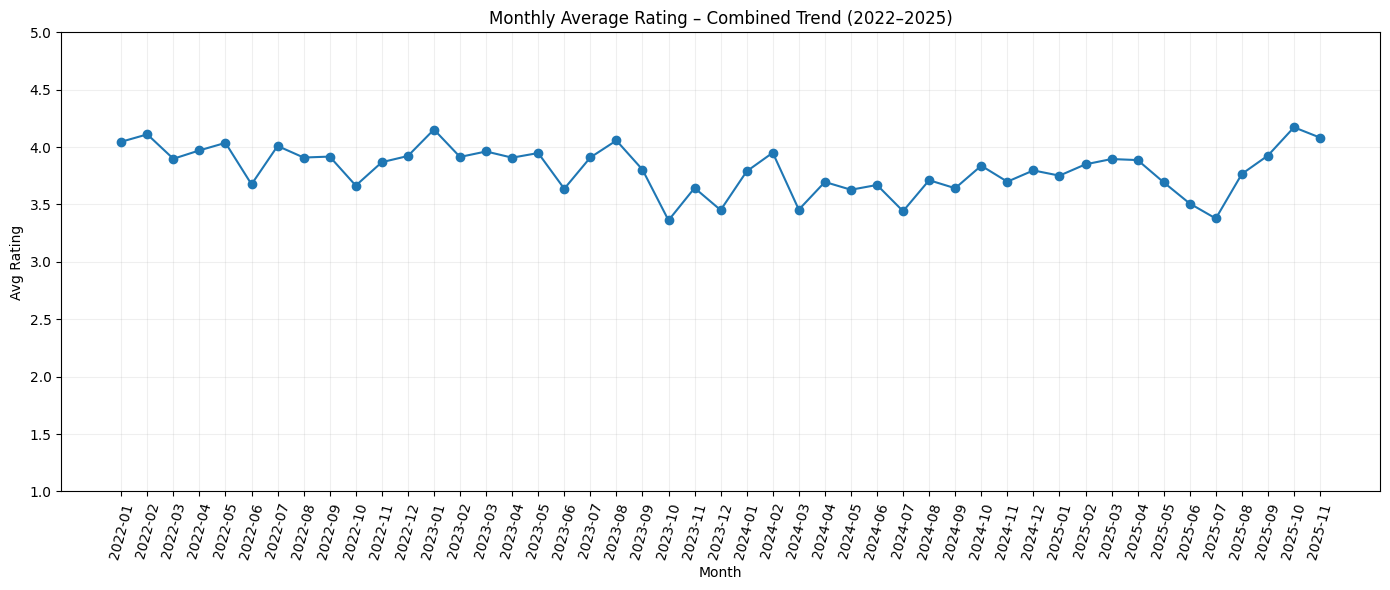

In [6]:
def plot_monthly_trend_all_years(df):
    # Parse dates safely
    df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)
    df = df.dropna(subset=['date'])

    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month

    # Filter only the years you want
    df = df[df['year'].between(2022, 2025)]

    # Aggregate by year + month
    monthly = df.groupby(['year', 'month'])['rating'].mean().reset_index()

    # Create a "time index" for plotting → ex: 2022-01, 2022-02,... 2025-12
    monthly['time'] = monthly['year'].astype(str) + "-" + monthly['month'].astype(str).str.zfill(2)

    # Plot
    plt.figure(figsize=(14, 6))
    plt.plot(monthly['time'], monthly['rating'], marker='o')

    plt.xticks(rotation=75)
    plt.title("Monthly Average Rating – Combined Trend (2022–2025)")
    plt.xlabel("Month")
    plt.ylabel("Avg Rating")
    plt.ylim(1, 5)
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_monthly_trend_all_years(df)

In [7]:
# 3) Aspect-Based Sentiment (simple keyword approach)
# Create aspect keyword dictionaries and compute aspect-level sentiment using VADER or simple polarity rule

ASPECT_KEYWORDS = {
    'staff': ['barista','staff','employee','manager','friendly','rude','helpful','attitude'],
    'speed': ['wait','slow','fast','queue','line','service','time','long wait','took'],
    'quality': ['taste','coffee','latte','espresso','cold','hot','flavor','quality'],
    'cleanliness': ['clean','dirty','smell','hygiene','toilet','bathroom','floor','tables'],
    'price': ['price','expensive','cheap','cost','overpriced','value'],
    'ambience': ['music','atmosphere','seating','space','table','crowd','ambience']
}

#creating aspect keywords that allow us to scan and categorize each keyword under specific criteria
#criteria for eg. staff, speed, quality

def extract_aspects(text, keywords=ASPECT_KEYWORDS):
    hits = {}
    if text is None:
        return hits
    for a, kws in keywords.items():
        for kw in kws:
            if kw in text:
                hits.setdefault(a, 0)
                hits[a] += 1
    return hits


def aspect_sentiment(df, text_col='review'):   # <-- FIXED HERE
    df2 = df.copy()
    
    # Ensure text is string
    df2[text_col] = df2[text_col].fillna("").astype(str)
    
    # If VADER is not available, fallback to rating-based sentiment
    if 'sid' not in globals() or sid is None:
        # fallback simple polarity using rating proxy (if rating exists)
        def get_sentiment_by_rating(row):
            if not np.isnan(row['rating']):
                # map rating to -1..1
                return (row['rating'] - 3) / 2
            return 0.0
        df2['polarity'] = df2.apply(get_sentiment_by_rating, axis=1)
    else:
        df2['polarity'] = df2[text_col].apply(lambda t: sid.polarity_scores(t)['compound'])

    # extract aspects and compute counts + polarity
    for aspect in ASPECT_KEYWORDS.keys():
        df2[aspect + '_count'] = df2[text_col].apply(
            lambda t: sum(t.count(kw) for kw in ASPECT_KEYWORDS[aspect])
        )
        
        # weighted polarity per aspect: polarity * count
        df2[aspect + '_polarity'] = df2.apply(
            lambda r: r['polarity'] * r[aspect + '_count'] if r[aspect + '_count'] > 0 else np.nan,
            axis=1
        )

    # aggregate
    cols = [c for c in df2.columns if c.endswith('_count') or c.endswith('_polarity')]
    
    agg = df2.groupby('store name')[cols].agg(['sum', 'mean', 'count'])

    return df2, agg


# ---- RUN THE ANALYSIS ----
df_aspect, store_aspect_scores = aspect_sentiment(df, text_col='review')


        

In [8]:
# ---- DISPLAY THE RESULTS ----
df_aspect.head()            


,store name,ownership type,city,review number,author,date,rating,review,month,year,...,speed_count,speed_polarity,quality_count,quality_polarity,cleanliness_count,cleanliness_polarity,price_count,price_polarity,ambience_count,ambience_polarity
0,New Oxford Street,Company Owned,London,1,Elena Martellucci,2024-06-21 21:18:08,5,"we had coffee, pastries, and a latte. it's a g...",6,2024,...,0,NaN,2,2.0,0,NaN,0,NaN,1,1.0
1,New Oxford Street,Company Owned,London,2,Anastasia Mikha,2024-06-21 22:54:06,3,i came to the establishment for my birthday (t...,6,2024,...,0,NaN,2,0.0,0,NaN,0,NaN,0,NaN
2,New Oxford Street,Company Owned,London,3,Parts LMC,2024-06-22 11:48:43,4,never disappointed with the drinks! always ver...,6,2024,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
3,New Oxford Street,Company Owned,London,4,Jennifer,2024-06-26 14:16:57,1,i was disappointed with this starburst in oxfo...,6,2024,...,1,-1.0,0,NaN,0,NaN,0,NaN,0,NaN
4,New Oxford Street,Company Owned,London,5,Tri Ngo Minh,2024-07-05 09:43:29,5,https://lh3.googleusercontent.com/geougc-cs/am...,7,2024,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN


In [9]:
store_aspect_scores

staff_count             staff_polarity  \
                                            sum  mean count            sum   
store name                                                                   
Aramark Canary Wharf                         43  0.43   100           -6.5   
Bayswater - Whiteleys                        45  0.45   100            6.5   
Beckenham - High Street                      64  0.64   100           -3.0   
Birmingham - Bullring - Middle West          75  0.75   100            4.0   
Birmingham - Colmore Row                     39  0.39   100           17.5   
...                                         ...   ...   ...            ...   
Villiers Street                              20  0.20   100            2.5   
Walbrook                                     26  0.26   100           -1.0   
Whitechapel Road                             43  0.43   100          -16.0   
Wimbledon Hill Road                          49  0.49   100           10.0   
Wood Lane Underground Station-               41  0.41   100           -2.0   

                                                    speed_count              \
                                         mean count         sum  mean count   
store name                                                                    
Aramark Canary Wharf                -0.270833    24          31  0.31   100   
Bayswater - Whiteleys                0.216667    30          31  0.31   100   
Beckenham - High Street             -0.090909    33          36  0.36   100   
Birmingham - Bullring - Middle West  0.102564    39          48  0.48   100   
Birmingham - Colmore Row             0.673077    26          36  0.36   100   
...                                       ...   ...         ...   ...   ...   
Villiers Street                      0.178571    14          35  0.35   100   
Walbrook                            -0.058824    17          23  0.23   100   
Whitechapel Road                    -0.666667    24          45  0.45   100   
Wimbledon Hill Road                  0.344828    29          41  0.41   100   
Wood Lane Underground Station-      -0.083333    24          37  0.37   100   

                                    speed_polarity  ... price_count  \
                                               sum  ...       count   
store name                                          ...               
Aramark Canary Wharf                           1.0  ...         100   
Bayswater - Whiteleys                          0.5  ...         100   
Beckenham - High Street                      -12.5  ...         100   
Birmingham - Bullring - Middle West           12.5  ...         100   
Birmingham - Colmore Row                      14.0  ...         100   
...                                            ...  ...         ...   
Villiers Street                                4.5  ...         100   
Walbrook                                       1.5  ...         100   
Whitechapel Road                              -7.5  ...         100   
Wimbledon Hill Road                           -3.0  ...         100   
Wood Lane Underground Station-               -20.0  ...         100   

                                    price_polarity                  \
                                               sum      mean count   
store name                                                           
Aramark Canary Wharf                          -6.0 -1.000000     6   
Bayswater - Whiteleys                         -2.0 -0.666667     3   
Beckenham - High Street                        0.5  0.500000     1   
Birmingham - Bullring - Middle West            0.5  0.166667     3   
Birmingham - Colmore Row                       1.5  0.750000     2   
...                                            ...       ...   ...   
Villiers Street                                0.5  0.500000     1   
Walbrook                                       0.0       NaN     0   
Whitechapel Road                               0.0  0.000000     2   
W

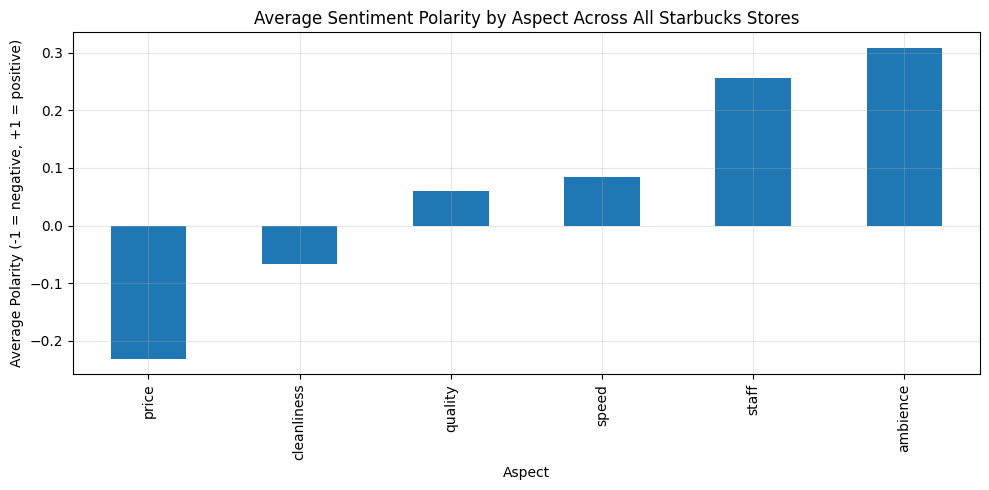

In [10]:
import matplotlib.pyplot as plt
#creating a graph to understand and compare growth of all criteria ie prize, cleaniness, quality, speed, staff amd ambience
# Select only the polarity mean columns from the multi-index
polarity_cols = [
    ('staff_polarity', 'mean'),
    ('speed_polarity', 'mean'),
    ('quality_polarity', 'mean'),
    ('cleanliness_polarity', 'mean'),
    ('price_polarity', 'mean'),
    ('ambience_polarity', 'mean')
]

# Extract them into a new dataframe
aspect_polarity_mean = store_aspect_scores[polarity_cols]

# Fix column names (flatten them)
aspect_polarity_mean.columns = [
    c[0].replace("_polarity", "") for c in polarity_cols
]

# Compute overall average polarity for each aspect across stores
avg_polarity = aspect_polarity_mean.mean().sort_values()

# ---- Plot ----
plt.figure(figsize=(10, 5))
avg_polarity.plot(kind='bar')
plt.title("Average Sentiment Polarity by Aspect Across All Starbucks Stores")
plt.ylabel("Average Polarity (-1 = negative, +1 = positive)")
plt.xlabel("Aspect")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Topic modeling (LDA)
#discovering hidden patterns or themes in reviews 
#Latent Dirichlet Allocation looks at all reviews and tries to group words into topics

#The LDA model ignores sentiment completely — it only groups words that frequently appear together.

#example
#topic: order speed & waiting
#words: wait, slow, long line, minutes, took, queue

#topic 0= a cluster of reviews that repeatedly use similar words


def lda_topics(df, text_col='review', n_topics=8, max_features=5000):
    vect = CountVectorizer(stop_words='english', max_features=max_features)

    # make sure text exists and is string
    X = vect.fit_transform(df[text_col].fillna('').astype(str))

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch'
    )
    lda.fit(X)

    terms = vect.get_feature_names_out()
    topics = []
    for idx, comp in enumerate(lda.components_):
        terms_idx = comp.argsort()[::-1][:15]
        topics.append([terms[i] for i in terms_idx])

    return lda, vect, topics



In [12]:
lda_model, lda_vectorizer, topics = lda_topics(df)

In [13]:
import matplotlib.pyplot as plt

def plot_topic(topics, topic_number=0, top_n=15):
    """
    Creates a horizontal bar chart of the top words in a selected topic.
    
    topics: list of topic word lists returned from LDA
    topic_number: which topic index to plot
    top_n: number of words to display
    """

    words = topics[topic_number][:top_n]
    scores = list(range(top_n, 0, -1))  # fake scores just for visualization

    plt.figure(figsize=(8, 5))
    plt.barh(words, scores)
    plt.gca().invert_yaxis()  # highest score at top
    plt.title(f"Top {top_n} Keywords for Topic {topic_number}")
    plt.xlabel("Importance (relative)")
    plt.tight_layout()
    plt.show()


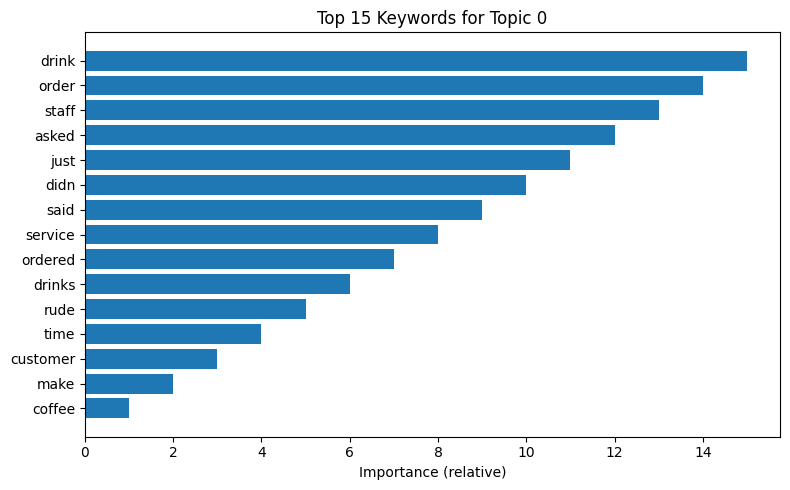

In [14]:
plot_topic(topics, topic_number=0)
#topic 0: representing order problems & drink preparation issues

#analysis:
#problems mentioned: long waits, drink errors, staff delays, confusion
#Starbucks should look into: improving order accuracy and workflow

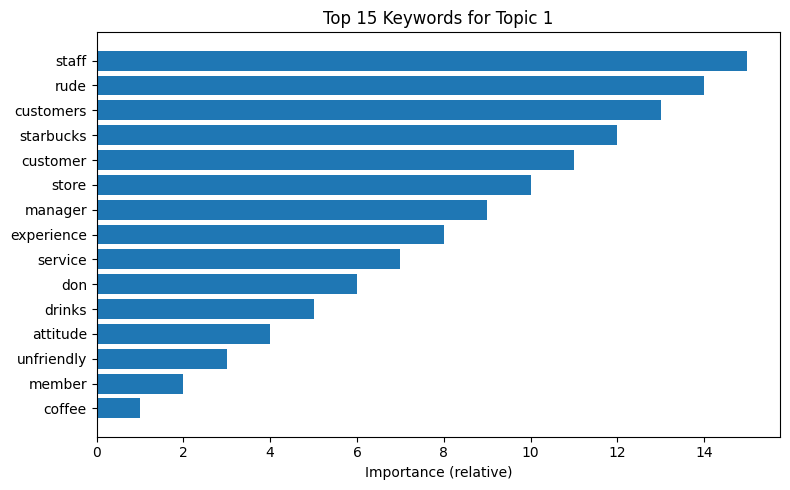

In [15]:
plot_topic(topics, topic_number=1)
#topic 1: customer complaints about staff attitude

#analysis:
#problems mentioned: rude and unfriendly behaviour 
#Starbucks should look into: improve customer service training and monitor staff interactions

In [16]:
#LDA analysis finding only negative comments for the topic
# keep only negative reviews
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['review'].apply(clean_text)

In [17]:
!pip install vaderSentiment


  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)


In [18]:
# Ensure vader is imported
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

# 1) Create a safe cleaned text column (fills NaN and ensures strings)
import re
def clean_text_safe(s):
    if s is None:
        return ""
    s = str(s)                 # convert floats/ints/NaN to string safely
    s = s.lower().strip()
    # optional: remove non-letter/number characters - keep it simple
    s = re.sub(r'\s+', ' ', s)
    return s

# create review_clean (won't overwrite if already exists, but will replace with safe cleaned text)
df['review_clean'] = df['review'].fillna("").astype(str).map(clean_text_safe)

# 2) Compute VADER polarity safely (works on strings)
df['review_polarity'] = df['review_clean'].apply(lambda x: sid.polarity_scores(x)['compound'])


# recommended VADER thresholds: negative < -0.05, neutral between -0.05 and 0.05, positive > 0.05
neg_count = (df['review_polarity'] < -0.05).sum()
neu_count = ((df['review_polarity'] >= -0.05) & (df['review_polarity'] <= 0.05)).sum()
pos_count = (df['review_polarity'] > 0.05).sum()
print(f"Negative: {neg_count}, Neutral: {neu_count}, Positive: {pos_count}")

# 4) Create df_neg for only negative reviews (use threshold -0.05)

df_neg.head()



Negative: 1553, Neutral: 4514, Positive: 3878


NameError: name 'df_neg' is not defined

In [ ]:
# Filter negative reviews (adjust column name as needed)
#negative_df = df[df['sentiment'] == 'negative'].copy()
# If you use ratings instead:
negative_df = df[df['rating'] <= 2].copy()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

def lda_topics(df, text_col='review', n_topics=4, max_features=5000):
    vect = CountVectorizer(stop_words='english', max_features=max_features)

    # make sure text exists
    X = vect.fit_transform(df[text_col].fillna('').astype(str))

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch'
    )
    lda.fit(X)

    terms = vect.get_feature_names_out()
    topics = []

    for idx, comp in enumerate(lda.components_):
        terms_idx = comp.argsort()[::-1][:15]
        topics.append([terms[i] for i in terms_idx])

    return lda, vect, topics


In [ ]:
lda_model_neg, lda_vectorizer_neg, neg_topics = lda_topics(negative_df)


In [ ]:
import matplotlib.pyplot as plt

def plot_topic(topics, topic_number=0, top_n=15):
    """
    Horizontal bar chart of top words in a selected topic.
    """
    words = topics[topic_number][:top_n]
    scores = list(range(top_n, 0, -1))  # fake scores for visual spacing

    plt.figure(figsize=(8, 5))
    plt.barh(words, scores)
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} Keywords for Topic {topic_number}")
    plt.xlabel("Importance (relative)")
    plt.tight_layout()
    plt.show()


In [ ]:
for i in range(4):
    plot_topic(neg_topics, topic_number=i)
